# Futures Pricing

Futures are standardised exchange-traded **contracts** to buy or sell an
underlying asset at a predetermined price on a future date. Futures are:
- necessarily cleared through a central counterparty (CCP)
- marked to market daily
- margined

Daily MTM, means daily P&L: 

$$
\text{Daily P\&L} = (F_{\text{today}} - F_{\text{yesterday}}) \times \text{contract size}
$$

Changes in regulations (EMIR, SOx) made most forwards more similar to futures in terms of CCP use, margining, and MTM, although differences remain due to the timing and scope of these rules for futures and forwards.

---

In the cost-of-carry model, the price of a pure forward contract is the no-arbitrage price. Excluding MTM and margining effects, this should equal the futures price. In practice, the theoretical cost-of-carry price is not exactly observed. The difference is called the basis, and futures prices deviate from the pure no-arbitrage carry value. The carry basis measures the deviation from the theoretical cost-of-carry model.

$$\text{Basis}_{\text{carry}} = F_{\text{mkt}} - S_0 e^{(r - q)T}
$$

<span style="font-size:small; color:gray">Do not confuse this with the spot basis (often written basis_spot), which measures the difference between the futures price and the spot price at the same time.:</span>
$$
\text{Basis}_{\text{futures}} = F_{t} - S_t
$$

<span style="font-size:small; color:gray">The sign of the basis leads to different nameas
* <span style="font-size:small; color:gray"> Ft > St: contango</span>
* <span style="font-size:small; color:gray"> Ft < St: backawardation</span>
</span>

In an ideal frictionless market, $\text{Basis}_{\text{carry}} = 0$. In practice it deviates due to:

* liquidity and supply/demand pressures
* hedging flows
* balance sheet and funding constraints

For futures, the main real economic effect is **daily margining and funding**: gains and losses are settled in cash each day and must be financed or reinvested at short-term interest rates. This affects the financing of the position, but it does not directly change the theoretical pricing formula.

The **convexity adjustment** refers to the difference between futures and forwards that arises when interest rates are stochastic and cashflows from daily settlement are reinvested over time, so the P&L of futures is path dependent. 

---

Note: Although in this notebook we are not working with convexity adjustments, here is a brief explanation about it. 

The convexity adjustment can be written as the difference between futures and "uncleared forwards"* driven by the covariance between the asset and the stochastic discount factor (exactly because the futueres P&L is path dependent):

$$
F_{\text{futures}} = F_{\text{uncleared forward}} + \mathrm{Cov}\left(D(0,T), S_T\right)
$$

where the discount factor is:

$$
D(0,T) = e^{-\int_0^T r_t dt}
$$

For pricing futures where the underlying are short-rates, this covariance term can be approximated using the Hull–White result:

$$
F_{\text{futures}} \approx F_{\text{uncleared forward}} \cdot \exp\left(\frac{1}{2}\sigma_r^2 T_1 T_2\right)
$$

where:

* $\sigma_r$ is the volatility of the short rate
* $T_1$ and $T_2$ are maturity-related terms depending on the contract structure






----
**Regulatory context:**
- FRTB SA -- equity futures (equity risk), bond futures (GIRR), FX futures (FX risk), commodity futures (commodity risk)
- EMIR -- exchange-traded futures are out of scope of the clearing obligation but subject to transaction reporting
- IFRS 13 -- Level 1 fair value (exchange-traded, active market)
- Basel IV -- futures generate counterparty credit risk via CCP exposure (but zero RW for qualifying CCPs)

**Contents:**
1. Cost of carry model
2. Equity index futures -- EuroStoxx 50
3. Bond futures -- Bund
4. FX futures -- EUR/USD CME
5. Commodity futures -- Brent crude
6. Margining mechanics
7. Basis and convergence
8. Roll yield
9. FRTB risk classification

In [1]:
from quant_risk.setup import base, asset_pricing

np, pd, plt = base()
ois_curve, nss_curve, valuation_date, calendar, ql = asset_pricing()

C1, C2, C3, C4 = '#2E75B6', '#ED7D31', '#A9D18E', '#C00000'
day_count = ql.Actual365Fixed()

base loaded
OISCurve | currency=EUR | valuation_date=2026-03-24
NSSCurve | currency=EUR | valuation_date=2026-05-04
Valuation date : March 24th, 2026
Calendar       : TARGET
asset pricing loaded


## 1. Cost of Carry Model

The futures price is derived from the spot price via the **cost of carry** model:

$$F(0,T) = S_0 \cdot e^{(r + c - y) \cdot T}$$

Where:
- $r$ -- risk-free rate (OIS)
- $c$ -- carrying cost (storage, insurance for commodities)
- $y$ -- convenience yield (benefit of holding the physical asset)
- $q$ -- dividend yield (for equity index futures: $F = S \cdot e^{(r-q)T}$

**By asset class:**

| Asset | Carry components | Futures premium/discount |
|-------|-----------------|-------------------------|
| Equity index | $r - q$ (rate minus dividend yield) | Contango if $r > q$; backwardation if $r < q$ |
| Government bond | $r - coupon$ (repo rate minus coupon) | Depends on repo specialness |
| FX | $r_{domestic} - r_{foreign}$ | CIP -- same as forward |
| Commodity | $r + c - y$ (rate + storage - convenience) | Contango or backwardation depending on $y$ |

**Futures vs Forwards:**

| Feature | Futures | Forwards |
|---------|---------|----------|
| Venue | Exchange | OTC |
| Clearing | CCP mandatory | Bilateral (or CCP for some) |
| Margining | Daily VM + IM | Bilateral CSA |
| Standardisation | Fixed contract size, expiry | Bespoke |
| Mark-to-market | Daily settlement | At maturity |
| Convexity adjustment | Yes -- daily settlement creates convexity vs forwards | No |

In [2]:
# ── cost of carry framework ───────────────────────────────────────────────────
# risk-free rate from OIS curve
def ois_rate(T):
    return ois_curve.zero_rate(T) / 100

def futures_price_equity(spot, T, div_yield):
    """Equity index futures -- F = S * exp((r - q) * T)"""
    r = ois_rate(T)
    return spot * np.exp((r - div_yield) * T)

def futures_price_fx(spot, T, r_foreign):
    """FX futures -- CIP: F = S * exp((r_dom - r_for) * T)"""
    r_dom = ois_rate(T)
    return spot * np.exp((r_dom - r_foreign) * T)

def futures_price_commodity(spot, T, storage_cost, convenience_yield):
    """Commodity futures -- F = S * exp((r + c - y) * T)"""
    r = ois_rate(T)
    return spot * np.exp((r + storage_cost - convenience_yield) * T)

tenors = [0.25, 0.5, 1.0, 2.0]
print(f"Cost of Carry -- Futures Prices by Asset Class")
print(f"Valuation date: {valuation_date}")
print(f"{'Tenor':<8}", end='')
print(f" {'OIS rate':>12}", end='')
print()
print("-" * 50)
for T in tenors:
    print(f"{T:<8.2f} {ois_rate(T)*100:>10.3f}%")

Cost of Carry -- Futures Prices by Asset Class
Valuation date: March 24th, 2026
Tenor        OIS rate
--------------------------------------------------
0.25          1.979%
0.50          2.052%
1.00          2.003%
2.00          2.131%


## 2. Equity Index Futures -- EuroStoxx 50

The **EURO STOXX 50 Future (FESX)** is the most liquid European equity
index future, traded on Eurex. Contract specifications:

| Specification | Detail |
|--------------|--------|
| Underlying | EURO STOXX 50 Index |
| Contract size | EUR 10 per index point |
| Expiry | March, June, September, December (IMM dates) |
| Settlement | Cash settlement |
| Exchange | Eurex |
| Tick size | 1 index point = EUR 10 |

**Pricing:** $F = S \cdot e^{(r-q) \cdot T}$ where $q$ is the dividend yield.

In [3]:
# ── EuroStoxx 50 futures pricing ─────────────────────────────────────────────
sx5e_spot   = 5250.0    # EURO STOXX 50 index level
div_yield   = 0.030     # 3.0% dividend yield -- typical for European equities
contract_sz = 10        # EUR 10 per index point
n_contracts = 10        # 10 contracts

print(f"EURO STOXX 50 Futures (FESX) -- Eurex")
print(f"Spot index:      {sx5e_spot:,.0f}")
print(f"Dividend yield:  {div_yield*100:.1f}%")
print(f"Contract size:   EUR {contract_sz} per point")
print(f"N contracts:     {n_contracts}")
print(f"\n{'Expiry':<8} {'OIS rate':>10} {'Futures':>10} {'vs Spot':>10} {'Notional EUR':>14}")
print("-" * 56)

futures_data_eq = {}
for T, label in [(0.25, 'Jun-26'), (0.5, 'Sep-26'), (1.0, 'Mar-27'), (2.0, 'Mar-28')]:
    r   = ois_rate(T)
    F   = futures_price_equity(sx5e_spot, T, div_yield)
    vs_spot = F - sx5e_spot
    notional = F * contract_sz * n_contracts
    futures_data_eq[label] = {'T': T, 'F': F, 'r': r}
    print(f"{label:<8} {r*100:>10.3f}% {F:>10.2f} {vs_spot:>+10.2f} {notional:>14,.0f}")

print(f"\nFutures < spot (backwardation) when div yield > OIS rate")
print(f"Current: OIS 1Y={ois_rate(1.0)*100:.2f}% vs div yield={div_yield*100:.1f}%")
if div_yield > ois_rate(1.0):
    print("=> Backwardation -- futures below spot")
else:
    print("=> Contango -- futures above spot")

EURO STOXX 50 Futures (FESX) -- Eurex
Spot index:      5,250
Dividend yield:  3.0%
Contract size:   EUR 10 per point
N contracts:     10

Expiry     OIS rate    Futures    vs Spot   Notional EUR
--------------------------------------------------------
Jun-26        1.979%    5236.61     -13.39        523,661
Sep-26        2.052%    5225.18     -24.82        522,518
Mar-27        2.003%    5197.90     -52.10        519,790
Mar-28        2.131%    5159.56     -90.44        515,956

Futures < spot (backwardation) when div yield > OIS rate
Current: OIS 1Y=2.00% vs div yield=3.0%
=> Backwardation -- futures below spot


### Risk measures

Equity index futures have a delta of approximately 1, meaning their value moves approximatelly one-for-one with the underlying index (in notional terms).

For regulatory capital (FRTB), the exposure is not used directly as “delta”, but converted into sensitivity-based risk. This exposure is then multiplied by a risk weight, which depends on the asset class and liquidity of the underlying (e.g. ~15% for large-cap developed equity indices).

In [4]:
# ── equity futures delta and FRTB equity risk ─────────────────────────────────
# Front contract = the nearest expiry contract - in this example a quarter ahead

T_front  = 0.25   # front month contract
F_front  = futures_price_equity(sx5e_spot, T_front, div_yield)
r_front  = ois_rate(T_front)

# delta -- sensitivity to 1% move in index
delta_eq = n_contracts * contract_sz * F_front * 0.01

# FRTB equity delta -- sensitivity-based
# delta = market value of position
mv_position = n_contracts * contract_sz * F_front
rw_equity   = 0.15   # 15% risk weight for large-cap IG equities (bucket 1)
ws_equity   = mv_position * rw_equity

print(f"Equity Futures Risk -- {n_contracts} FESX Jun-26 contracts")
print(f"Front futures price:   {F_front:.2f}")
print(f"Position MV:           EUR {mv_position:,.0f}")
print(f"Delta (1% index move): EUR {delta_eq:,.0f}")
print(f"\nFRTB SA Equity Risk:")
print(f"  Risk weight:           {rw_equity*100:.0f}%")
print(f"  Weighted sensitivity:  EUR {ws_equity:,.0f}")

Equity Futures Risk -- 10 FESX Jun-26 contracts
Front futures price:   5236.61
Position MV:           EUR 523,661
Delta (1% index move): EUR 5,237

FRTB SA Equity Risk:
  Risk weight:           15%
  Weighted sensitivity:  EUR 78,549


## 3. Bond Futures: Bund

The **Euro Bund Future (FGBL)** is the benchmark European government bond
future, tracking 10-year German Bunds. Contract specifications:

| Specification | Detail |
|--------------|--------|
| Underlying | Notional 6% 10Y German government bond |
| Contract size | EUR 100,000 nominal |
| Expiry | March, June, September, December |
| Settlement | Physical delivery of eligible bonds |
| Exchange | Eurex |
| Cheapest to deliver | Short side delivers cheapest eligible bond |

**Conversion factor:** adjusts for the difference between the coupon of
the delivered bond and the 6% notional coupon. The futures price is derived in two steps.

**Step 1: economic forward price**

No contract rules yet. This is the **economic** forward value of the bond future.

$$
F_{\text{bond}} = \left(S_{\text{dirty}} - PV(\text{coupons during life})\right)e^{rT}
$$

Equivalent form:

$$
F_{\text{bond}} = S_{\text{dirty}} \, e^{rT} - FV(\text{coupons})
$$

**Step 2: contract rules and quotation convention**

The futures contract covers a basket of eligible bonds. Each bond $i$ has a
conversion factor $CF_i$, which normalises its price relative to the 6% notional
coupon. This is a **quotation convention**, not a delivery right.

$$
F_{\text{fut}} = \frac{F_{\text{bond}}}{CF}
$$

$$
F_{\text{fut}} = \frac{S_{\text{dirty}} \, e^{rT} - FV(\text{coupons})}{CF}
$$

**Cheapest to deliver (CTD)**

The short selects which eligible bond to deliver, choosing the one that minimises delivery cost.

$$
\text{CTD} = \arg\min_{i} \left( S_i - F_{\text{fut}} \times CF_i \right)
$$

**Settlement**

The short delivers the CTD and receives the invoice price:

$$
\text{Invoice} = F_{\text{fut}} \times CF_{\text{CTD}} + AI_{\text{delivery}}
$$

where $AI_{\text{delivery}}$ is the accrued interest on the delivered bond at the
delivery date, and $FV(\text{coupons})$ denotes the future value of coupons paid
during the life of the futures contract.

In [5]:
# ── Bund futures pricing ──────────────────────────────────────────────────────
# CTD bond: Bund 2.5% Aug 2034 -- approximate current CTD
bund_clean_price = 95.50     # clean price per 100 nominal
bund_coupon      = 2.50      # 2.50% annual coupon
bund_ai          = 0.75      # accrued interest (approximate)
bund_dirty_price = bund_clean_price + bund_ai
conversion_factor = 0.8950   # CTD conversion factor
contract_size_bund = 100_000  # EUR 100,000 nominal
n_bund = 50                   # 50 contracts

T_bund = 0.25   # front quarterly expiry
r_bund = ois_rate(T_bund)

# coupon payment during futures life -- assume no coupon in 3M period
fv_coupon = 0.0

# invoice price formula
# futures price * conversion factor + AI at delivery = invoice price
futures_price_bund = ((bund_dirty_price * np.exp(r_bund * T_bund) - fv_coupon)
                      / conversion_factor)

notional_bund = n_bund * contract_size_bund * futures_price_bund / 100

print(f"Euro Bund Future (FGBL) -- Eurex")
print(f"CTD bond:           Bund 2.5% Aug 2034")
print(f"Clean price:        {bund_clean_price:.2f}")
print(f"Accrued interest:   {bund_ai:.2f}")
print(f"Dirty price:        {bund_dirty_price:.2f}")
print(f"Conversion factor:  {conversion_factor:.4f}")
print(f"OIS rate (3M):      {r_bund*100:.3f}%")
print(f"\nFutures price:      {futures_price_bund:.4f}")
print(f"N contracts:        {n_bund}")
print(f"Total notional:     EUR {notional_bund:,.0f}")

# DV01 of futures position
# approximate: DV01 ≈ modified duration * dirty price * contract size * n_contracts / 10000
mod_dur_bund = 8.5   # approximate modified duration of CTD
dv01_bund = mod_dur_bund * bund_dirty_price / 100 * contract_size_bund * n_bund / 10000
print(f"\nDV01 (approx):      EUR {dv01_bund:,.0f} per 1bp")
print(f"\nFRTB GIRR -- bond futures DV01 feeds into GIRR 10Y tenor bucket")

Euro Bund Future (FGBL) -- Eurex
CTD bond:           Bund 2.5% Aug 2034
Clean price:        95.50
Accrued interest:   0.75
Dirty price:        96.25
Conversion factor:  0.8950
OIS rate (3M):      1.979%

Futures price:      108.0752
N contracts:        50
Total notional:     EUR 5,403,759

DV01 (approx):      EUR 4,091 per 1bp

FRTB GIRR -- bond futures DV01 feeds into GIRR 10Y tenor bucket


#### Rate futures vs. Bond futures
| Feature | Rate Futures | Bond Futures |
|---|---|---|
| Underlying | Reference rate (SOFR, Euribor, swap rate) | Basket of deliverable bonds with CTD mechanism |
| Tenors | Any, short to long end | Typically 2Y, 5Y, 10Y, 30Y |
| Pricing | 100 minus implied forward rate | Cost of carry on CTD bond, adjusted by conversion factor |
| Settlement | Cash | Physical delivery of CTD bond |
| DV01 | Fixed and known per contract | Varies with CTD duration and conversion factor |
| CTD / basis risk | None | Yes, CTD can switch, creating basis risk |
| Convexity adjustment | adjustment = Cov(discount factor, rate); Hull-White gives standard approximation | Same daily MTM mechanism applies; adjustment = Cov(discount factor, bond price) |
| Liquidity (long end) | Lower than bond futures | Higher, especially Bund, Treasury, BTP |
| Best use | Pure rate exposure, clean curve positioning | Duration management, bond portfolio hedging, curve trades |

## 4. FX Futures -- EUR/USD CME

FX futures on CME are functionally equivalent to FX forwards but
exchange-traded, standardised, and CCP-cleared.

| Specification | Detail |
|--------------|--------|
| Underlying | EUR/USD |
| Contract size | EUR 125,000 |
| Expiry | March, June, September, December |
| Settlement | Physical delivery of EUR |
| Exchange | CME |
| Pricing | Identical to CIP forward |

**Pricing:** identical to FX forward via CIP -- $F = S \cdot e^{(r_{EUR} - r_{USD}) \cdot T}$

In [6]:
# ── EUR/USD FX futures ────────────────────────────────────────────────────────
spot_eurusd   = 1.1578
r_usd_3m      = 0.0374
r_eur_3m      = ois_rate(0.25)
contract_fx   = 125_000   # EUR 125,000 per contract
n_fx          = 8         # 8 contracts = EUR 1M

tenors_fx = {'Jun-26': 0.25, 'Sep-26': 0.5, 'Dec-26': 0.75, 'Mar-27': 1.0}
usd_rates_fx = {0.25: 0.0374, 0.5: 0.0378, 0.75: 0.0380, 1.0: 0.0381}

print(f"EUR/USD FX Futures -- CME")
print(f"Spot EUR/USD: {spot_eurusd:.4f}")
print(f"Contract size: EUR {contract_fx:,.0f}")
print(f"\n{'Expiry':<10} {'EUR OIS':>10} {'USD rate':>10} {'Futures':>10} {'Fwd pts':>10}")
print("-" * 54)
for label, T in tenors_fx.items():
    r_eur = ois_rate(T)
    r_usd = usd_rates_fx[T]
    F_fx  = spot_eurusd * np.exp((r_eur - r_usd) * T)
    fwd_pts = (F_fx - spot_eurusd) * 10000
    print(f"{label:<10} {r_eur*100:>10.3f}% {r_usd*100:>10.3f}% {F_fx:>10.4f} {fwd_pts:>8.1f}pp")

EUR/USD FX Futures -- CME
Spot EUR/USD: 1.1578
Contract size: EUR 125,000

Expiry        EUR OIS   USD rate    Futures    Fwd pts
------------------------------------------------------
Jun-26          1.979%      3.740%     1.1527    -50.9pp
Sep-26          2.052%      3.780%     1.1478    -99.6pp
Dec-26          1.984%      3.800%     1.1421   -156.6pp
Mar-27          2.003%      3.810%     1.1371   -207.4pp


## 5. Commodity Futures -- Brent Crude

Commodity futures pricing reflects:
* cost of carry
* physical storage costs
* convenience yield -- the benefit of holding the physical commodity (operational flexibility, scarcity premium).

**Contango:** futures price > spot -- storage costs dominate, convenience yield low.
Normal market structure when supply is ample.

**Backwardation:** futures price < spot -- convenience yield dominates,
physical supply is tight. Common in oil and agricultural markets during supply crunches.

**Roll yield:** the gain or loss from rolling a futures position as it approaches expiry.
In contango: negative roll yield (roll from cheaper near to more expensive far).
In backwardation: positive roll yield (roll from more expensive near to cheaper far).

In [7]:
# ── Brent crude futures ───────────────────────────────────────────────────────
brent_spot    = 72.50   # USD per barrel
storage_cost  = 0.015   # 1.5% per year -- storage, insurance, transport

# convenience yield varies -- high in supply squeeze, low in glut
# current environment: moderate supply, mild contango
conv_yield    = 0.010   # 1.0% -- low convenience yield

# approximate USD risk-free rate
r_usd_approx  = 0.0381

print(f"Brent Crude Futures")
print(f"Spot price:        USD {brent_spot:.2f}/bbl")
print(f"Storage cost:      {storage_cost*100:.1f}% pa")
print(f"Convenience yield: {conv_yield*100:.1f}% pa")
print(f"Net carry:         {(r_usd_approx + storage_cost - conv_yield)*100:.2f}% pa")
print(f"\n{'Expiry':<10} {'Futures':>10} {'vs Spot':>10} {'Structure':>12}")
print("-" * 46)
for months, label in [(1, '1M'), (3, '3M'), (6, '6M'), (12, '1Y'), (24, '2Y')]:
    T     = months / 12
    F_com = futures_price_commodity(brent_spot, T, storage_cost, conv_yield)
    vs_spot = F_com - brent_spot
    structure = 'Contango' if F_com > brent_spot else 'Backwardation'
    print(f"{label:<10} {F_com:>10.2f} {vs_spot:>+10.2f} {structure:>12}")

Brent Crude Futures
Spot price:        USD 72.50/bbl
Storage cost:      1.5% pa
Convenience yield: 1.0% pa
Net carry:         4.31% pa

Expiry        Futures    vs Spot    Structure
----------------------------------------------
1M              72.65      +0.15     Contango
3M              72.95      +0.45     Contango
6M              73.43      +0.93     Contango
1Y              74.34      +1.84     Contango
2Y              76.42      +3.92     Contango


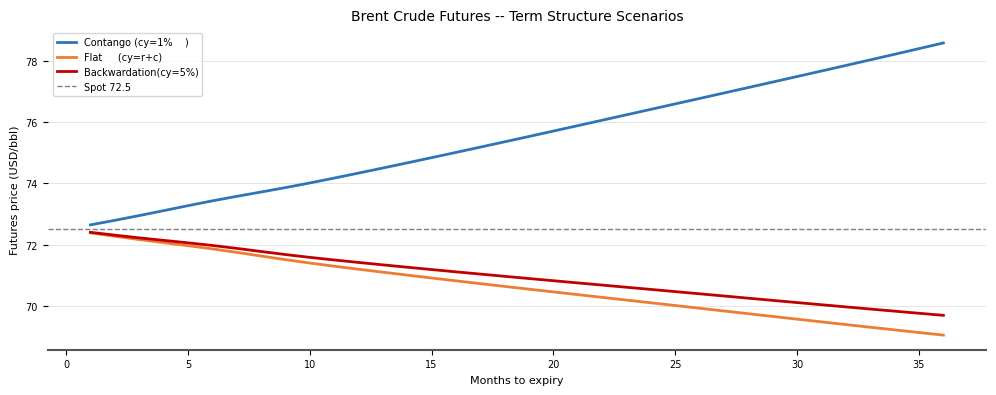

In [8]:
# ── term structure visualisation ──────────────────────────────────────────────
months_range = np.arange(1, 37)
T_range      = months_range / 12

# three scenarios: contango, flat, backwardation
scenarios_com = {
    'Contango (cy=1%    )': 0.010,
    'Flat     (cy=r+c)  ': r_usd_approx + storage_cost,
    'Backwardation(cy=5%)': 0.050,
}

fig, ax = plt.subplots(figsize=(10, 4))
colors_com = [C1, C2, C4]
for (label, cy), color in zip(scenarios_com.items(), colors_com):
    prices = [futures_price_commodity(brent_spot, T, storage_cost, cy) for T in T_range]
    ax.plot(months_range, prices, color=color, linewidth=2, label=label)

ax.axhline(brent_spot, color='grey', linestyle='--', linewidth=1, label=f'Spot {brent_spot}')
ax.set_xlabel('Months to expiry')
ax.set_ylabel('Futures price (USD/bbl)')
ax.set_title('Brent Crude Futures -- Term Structure Scenarios')
ax.legend()
ax.spines['bottom'].set_color('#555555')
plt.tight_layout()
plt.show()

## 6. Margining Mechanics

Futures require two types of margin posted to the CCP:

**Initial margin (IM):** posted upfront to cover potential losses over the
margin period of risk (typically 1-2 days). Set by the exchange/CCP based
on historical volatility. Not available to the holder -- posted as collateral.

**Variation margin (VM):** daily cash settlement of mark-to-market gains
and losses. If the futures price moves against you, you pay VM to the CCP.
If it moves in your favour, you receive VM. This is the key difference
from forwards -- no cash flow at maturity, only daily settlements.

Margining Simulation -- 10 FESX Contracts
Entry price:      5236.61
Notional:         EUR 523,661
Initial margin:   EUR 26,183 (5% of notional)

Day         Price     Daily VM      Cum P&L
--------------------------------------------
1         5267.90        +3129        +3129
2         5259.19         -871        +2258
3         5300.00        +4080        +6339
4         5395.95        +9595       +15934
5         5381.20        -1475       +14459
6         5366.45        -1475       +12984
7         5465.94        +9949       +22933
8         5514.29        +4835       +27767
9         5484.71        -2958       +24810
10        5518.89        +3418       +28228


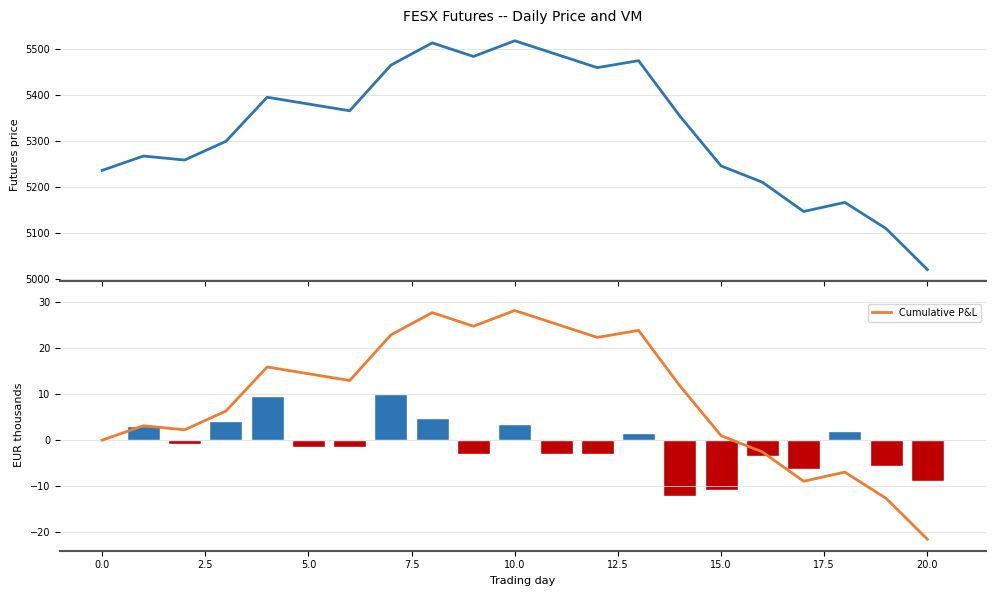

In [ ]:
# ── margining simulation -- EuroStoxx 50 futures ─────────────────────────────
np.random.seed(42)

# contract parameters
F_entry      = futures_price_equity(sx5e_spot, 0.25, div_yield)
n_contracts  = 10
contract_sz  = 10   # EUR 10 per point

# initial margin -- approx 5% of notional for FESX
im_pct       = 0.05
initial_margin = im_pct * F_entry * contract_sz * n_contracts

# simulate 20 trading days of price moves
n_days  = 20
daily_vol = sx5e_spot * 0.012   # ~1.2% daily vol for SX5E
price_changes = np.random.normal(0, daily_vol, n_days)
prices  = [F_entry] + list(F_entry + np.cumsum(price_changes))

# daily VM
vm_daily = []
cum_pnl  = [0]
for i in range(1, len(prices)):
    vm = (prices[i] - prices[i-1]) * contract_sz * n_contracts
    vm_daily.append(vm)
    cum_pnl.append(cum_pnl[-1] + vm)

print(f"Margining Simulation -- {n_contracts} FESX Contracts")
print(f"Entry price:      {F_entry:.2f}")
print(f"Notional:         EUR {F_entry*contract_sz*n_contracts:,.0f}")
print(f"Initial margin:   EUR {initial_margin:,.0f} ({im_pct*100:.0f}% of notional)")
print(f"\n{'Day':<6} {'Price':>10} {'Daily VM':>12} {'Cum P&L':>12}")
print("-" * 44)
for i in range(min(10, n_days)):
    print(f"{i+1:<6} {prices[i+1]:>10.2f} {vm_daily[i]:>+12.0f} {cum_pnl[i+1]:>+12.0f}")

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
days = list(range(n_days + 1))
ax0.plot(days, prices, color=C1, linewidth=2)
ax0.set_ylabel('Futures price')
ax0.set_title('FESX Futures -- Daily Price and VM')
ax0.spines['bottom'].set_color('#555555')

colors_vm = [C1 if v >= 0 else C4 for v in vm_daily]
ax1.bar(range(1, n_days+1), [v/1000 for v in vm_daily], color=colors_vm, edgecolor='white')
ax1.plot(days, [p/1000 for p in cum_pnl], color=C2, linewidth=2, label='Cumulative P&L')
ax1.set_ylabel('EUR thousands')
ax1.set_xlabel('Trading day')
ax1.legend()
ax1.spines['bottom'].set_color('#555555')

plt.tight_layout()
plt.show()

## 7. Basis and Convergence

**Basis** = Spot price - Futures price

At expiry, basis converges to zero (delivery arbitrage ensures this).
Before expiry, basis reflects the cost of carry and any temporary
supply/demand imbalances.

**Basis risk:** the risk that the relationship between spot and futures
moves unexpectedly -- a hedger who uses futures to hedge a spot position
is left with residual basis risk.

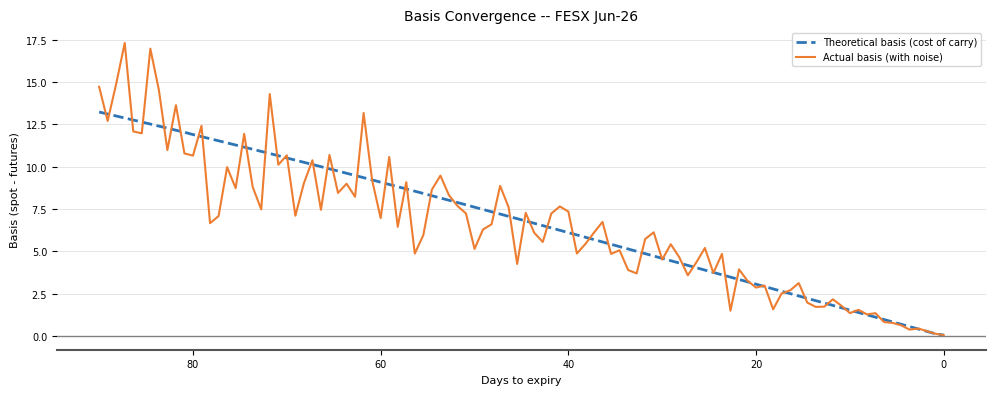

In [10]:
# ── basis and convergence ────────────────────────────────────────────────────
days_to_expiry = np.linspace(90, 0, 100)
T_range_basis  = days_to_expiry / 365

# theoretical basis -- cost of carry
basis_theoretical = [
    sx5e_spot - futures_price_equity(sx5e_spot, max(T, 0.001), div_yield)
    for T in T_range_basis
]

# add noise to simulate actual basis
np.random.seed(42)
noise = np.random.normal(0, 3, len(T_range_basis)) * (days_to_expiry / 90)
basis_actual = np.array(basis_theoretical) + noise

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(days_to_expiry, basis_theoretical, color=C1, linewidth=2,
        linestyle='--', label='Theoretical basis (cost of carry)')
ax.plot(days_to_expiry, basis_actual, color=C2, linewidth=1.5,
        label='Actual basis (with noise)')
ax.axhline(0, color='grey', linewidth=1)
ax.set_xlabel('Days to expiry')
ax.set_ylabel('Basis (spot - futures)')
ax.set_title('Basis Convergence -- FESX Jun-26')
ax.invert_xaxis()
ax.legend()
ax.spines['bottom'].set_color('#555555')
plt.tight_layout()
plt.show()

## 8. Roll Yield

A futures position must be rolled before expiry -- the near contract
is sold and the far contract is bought. The roll yield is the P&L
from this roll:

$$Roll\ yield = \frac{F_{near} - F_{far}}{F_{near}} \times \frac{365}{days\ between\ expiries}$$

Positive in backwardation (near > far), negative in contango (near < far).
Roll yield is a significant component of total return for commodity strategies.

In [11]:
# ── roll yield calculation ────────────────────────────────────────────────────
print("Roll Yield by Asset and Market Structure")
print(f"{'Asset':<20} {'Near':>10} {'Far':>10} {'Roll yield':>12} {'Structure':>14}")
print("-" * 70)

roll_examples = [
    ('FESX (contango)',    futures_price_equity(sx5e_spot, 0.25, div_yield),
                          futures_price_equity(sx5e_spot, 0.50, div_yield), 91),
    ('Brent (contango)',   futures_price_commodity(brent_spot, 1/12, storage_cost, 0.01),
                          futures_price_commodity(brent_spot, 2/12, storage_cost, 0.01), 30),
    ('Brent (backw.)',     futures_price_commodity(brent_spot, 1/12, storage_cost, 0.05),
                          futures_price_commodity(brent_spot, 2/12, storage_cost, 0.05), 30),
]

for label, F_near, F_far, days in roll_examples:
    roll_yield = (F_near - F_far) / F_near * 365 / days * 100
    structure  = 'Backwardation' if F_near > F_far else 'Contango'
    print(f"{label:<20} {F_near:>10.2f} {F_far:>10.2f} {roll_yield:>10.2f}% {structure:>14}")

Roll Yield by Asset and Market Structure
Asset                      Near        Far   Roll yield      Structure
----------------------------------------------------------------------
FESX (contango)         5236.61    5225.18       0.88%  Backwardation
Brent (contango)          72.65      72.80      -2.49%       Contango
Brent (backw.)            72.41      72.31       1.56%  Backwardation


## 9. FRTB Risk Classification

Under CRR3 / FRTB SA, futures positions are classified by risk class:

| Futures type | FRTB risk class | Key sensitivity |
|-------------|----------------|----------------|
| Equity index (FESX) | Equity risk | Delta equity -- MV × risk weight |
| Bond (FGBL) | GIRR | Delta IR -- DV01 per tenor vertex |
| FX (EUR/USD CME) | FX risk | Delta FX -- 1% spot sensitivity |
| Commodity (Brent) | Commodity risk | Delta commodity -- MV × risk weight |

Exchange-traded futures: IFRS 13 Level 1 (quoted price in active market).
No CVA capital for exchange-traded futures (qualifying CCP -- zero RW).

In [12]:
# ── FRTB summary across futures positions ─────────────────────────────────────
frtb_futures = pd.DataFrame([
    {
        'Position':       '10x FESX Jun-26',
        'Risk class':     'Equity',
        'MV (EUR)':       F_front * contract_sz * 10,
        'Risk weight':    '15%',
        'Capital (EUR)':  F_front * contract_sz * 10 * 0.15,
        'IFRS 13 level':  'Level 1',
    },
    {
        'Position':       '50x FGBL Jun-26',
        'Risk class':     'GIRR',
        'MV (EUR)':       futures_price_bund * contract_size_bund * n_bund / 100,
        'Risk weight':    '1.1% (10Y)',
        'Capital (EUR)':  dv01_bund * 0.011 / 0.0001,
        'IFRS 13 level':  'Level 1',
    },
    {
        'Position':       '8x EUR/USD CME',
        'Risk class':     'FX',
        'MV (EUR)':       contract_fx * 8,
        'Risk weight':    '15%',
        'Capital (EUR)':  contract_fx * 8 * 0.15,
        'IFRS 13 level':  'Level 1',
    },
    {
        'Position':       '100x Brent 1M',
        'Risk class':     'Commodity',
        'MV (EUR)':       brent_spot * 1000 * 100 / spot_eurusd,
        'Risk weight':    '25% (energy)',
        'Capital (EUR)':  brent_spot * 1000 * 100 / spot_eurusd * 0.25,
        'IFRS 13 level':  'Level 1',
    },
])

print("FRTB SA Capital -- Futures Portfolio:")
print(frtb_futures.to_string(index=False))
print(f"\nTotal FRTB capital (simplified, no correlation netting): EUR {frtb_futures['Capital (EUR)'].sum():,.0f}")

FRTB SA Capital -- Futures Portfolio:
       Position Risk class       MV (EUR)  Risk weight  Capital (EUR) IFRS 13 level
10x FESX Jun-26     Equity  523661.158220          15%   78549.173733       Level 1
50x FGBL Jun-26       GIRR 5403759.031124   1.1% (10Y)  449968.750000       Level 1
 8x EUR/USD CME         FX 1000000.000000          15%  150000.000000       Level 1
  100x Brent 1M  Commodity 6261875.971670 25% (energy) 1565468.992918       Level 1

Total FRTB capital (simplified, no correlation netting): EUR 2,243,987


## Summary

| Concept | Key result | Reference |
|---------|-----------|----------|
| Cost of carry | $F = S \cdot e^{(r+c-y)T}$ | No-arbitrage |
| Equity futures | Backwardation when div yield > OIS | FESX/Eurex |
| Bond futures | CTD and conversion factor drive price | FGBL/Eurex |
| FX futures | Identical to CIP forward | CME/EUR/USD |
| Commodity | Contango (storage) vs backwardation (convenience) | Brent/ICE |
| Margining | Daily VM + upfront IM -- no maturity cash flow | CCP/EMIR |
| Roll yield | Negative in contango, positive in backwardation | Market structure |
| FRTB | Equity/GIRR/FX/Commodity risk classes | CRR3 Article 325 |
| IFRS 13 | Level 1 -- exchange-traded active market | IFRS 13.9 |

---
*Notebook QRE-41 | Sprint 5 | Quant Risk Engine*  
*Regulation: CRR3 (EU 2024/1623) FRTB SA, EMIR (EU 648/2012), IFRS 13*